In [1]:
import numpy as np
import pandas as pd

np.random.seed(23) 

# Class 1
mu_vec1 = np.array([0,0,0])
cov_mat1 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, 20)

df = pd.DataFrame(class1_sample, columns=['feature1','feature2','feature3'])
df['target'] = 1

# Class 2
mu_vec2 = np.array([1,1,1])
cov_mat2 = np.array([[1,0,0],[0,1,0],[0,0,1]])
class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, 20)

df1 = pd.DataFrame(class2_sample, columns=['feature1','feature2','feature3'])
df1['target'] = 0

# FIXED LINE: pd.concat takes a list of dataframes
df = pd.concat([df, df1], ignore_index=True, axis=0)

# Shuffle the dataset
df = df.sample(40)

In [5]:
df

,feature1,feature2,feature3,target
2,-0.700809,-1.525586,-1.749156,1
34,-0.224481,-1.010757,0.491251,0
14,-0.011456,-0.046935,-0.649616,1
11,1.342296,-0.962723,-1.184163,1
12,-2.571350,-0.299561,-0.054040,1
29,0.867118,0.935791,-0.426437,0
31,1.566196,-0.219914,0.461019,0
4,-0.097477,-0.382241,-1.504166,1
32,-1.011917,0.954984,-0.661960,0
33,2.090049,-0.757570,1.731490,0


In [2]:
df.shape

(40, 4)

In [3]:
import plotly.express as px
#y_train_trf = y_train.astype(str)
fig = px.scatter_3d(df, x=df['feature1'], y=df['feature2'], z=df['feature3'],
              color=df['target'].astype('str'))
fig.update_traces(marker=dict(size=12,
                              line=dict(width=2,
                                        color='DarkSlateGrey')),
                  selector=dict(mode='markers'))

fig.show()

In [4]:
# Step 1 - Apply standard scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

df.iloc[:,0:3] = scaler.fit_transform(df.iloc[:,0:3])

In [6]:
# Step 2 - Find Covariance Matrix
covariance_matrix = np.cov([df.iloc[:,0],df.iloc[:,1],df.iloc[:,2]])
print('Covariance Matrix:\n', covariance_matrix)

Covariance Matrix:
 [[1.02564103 0.20478114 0.080118  ]
 [0.20478114 1.02564103 0.19838882]
 [0.080118   0.19838882 1.02564103]]


In [7]:
# Step 3 - Finding EV and EVs
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [8]:
eigen_values

array([1.3536065 +0.j, 0.94557084+0.j, 0.77774573+0.j])

In [9]:
eigen_vectors

array([[-0.53875915+0.j, -0.69363291+0.j,  0.47813384+0.j],
       [-0.65608325+0.j, -0.01057596+0.j, -0.75461442+0.j],
       [-0.52848211+0.j,  0.72025103+0.j,  0.44938304+0.j]])

/Users/ishanarora18/Library/Python/3.14/lib/python/site-packages/matplotlib/transforms.py:1913: ComplexWarning: Casting complex values to real discards the imaginary part
  return affine_transform(values, mtx)


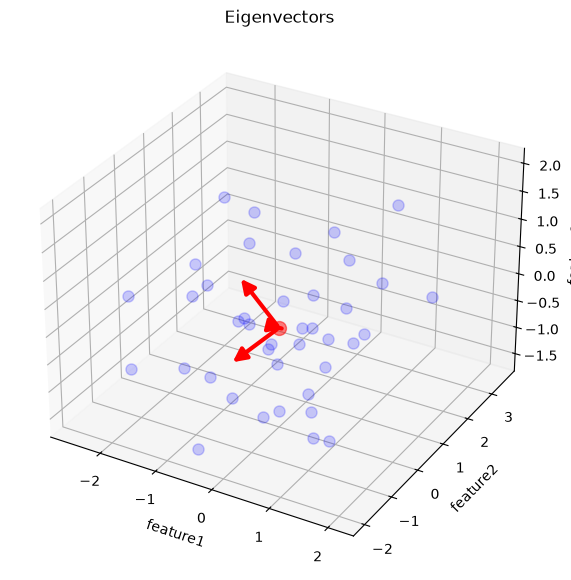

In [18]:
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d import proj3d
from matplotlib.patches import FancyArrowPatch
import numpy as np

# 1. Updated Arrow3D class for modern Matplotlib
class Arrow3D(FancyArrowPatch):
    def __init__(self, xs, ys, zs, *args, **kwargs):
        super().__init__((0,0), (0,0), *args, **kwargs)
        self._verts3d = xs, ys, zs

    def draw(self, renderer):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        super().draw(renderer)
        
    def do_3d_projection(self, renderer=None):
        xs3d, ys3d, zs3d = self._verts3d
        xs, ys, zs = proj3d.proj_transform(xs3d, ys3d, zs3d, self.axes.M)
        self.set_positions((xs[0],ys[0]),(xs[1],ys[1]))
        return np.min(zs)

fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(111, projection='3d')

# Calculate means once for cleaner code
mean_x = df['feature1'].mean()
mean_y = df['feature2'].mean()
mean_z = df['feature3'].mean()

ax.plot(df['feature1'], df['feature2'], df['feature3'], 'o', markersize=8, color='blue', alpha=0.2)
ax.plot([mean_x], [mean_y], [mean_z], 'o', markersize=10, color='red', alpha=0.5)

# 2. Corrected endpoint math (mean + eigenvector)
for v in eigen_vectors.T:
    a = Arrow3D(
        [mean_x, mean_x + v[0]], 
        [mean_y, mean_y + v[1]], 
        [mean_z, mean_z + v[2]], 
        mutation_scale=20, lw=3, arrowstyle="-|>", color="r"
    )
    ax.add_artist(a)

ax.set_xlabel('feature1')
ax.set_ylabel('feature2')
ax.set_zlabel('feature3')

plt.title('Eigenvectors')
plt.show()

In [20]:
pc = eigen_vectors[0:2]
pc

array([[-0.53875915+0.j, -0.69363291+0.j,  0.47813384+0.j],
       [-0.65608325+0.j, -0.01057596+0.j, -0.75461442+0.j]])

In [22]:
transformed_df = np.dot(df.iloc[:,0:3],pc.T)
# 40,3 - 3,2
new_df = pd.DataFrame(transformed_df,columns=['PC1','PC2'])
new_df['target'] = df['target'].values
new_df.head()

,PC1,PC2,target
0,0.599433+0.000000j,1.795862+0.000000j,1
1,1.056919+0.000000j,-0.212737+0.000000j,0
2,-0.271876+0.000000j,0.498222+0.000000j,1
3,-0.621586+0.000000j,0.023110+0.000000j,1
4,1.567286+0.000000j,1.730967+0.000000j,1


In [28]:
import numpy as np
import plotly.express as px

# Strip away any imaginary parts (+0.0j) from the numpy eig calculation
new_df['PC1'] = np.real(new_df['PC1'])
new_df['PC2'] = np.real(new_df['PC2'])

# Target conversion
new_df['target'] = new_df['target'].astype('str')

# Now plot as normal
fig = px.scatter(
    data_frame=new_df,
    x='PC1',
    y='PC2',
    color='target',
    color_discrete_sequence=px.colors.qualitative.G10,
    title='PCA: 2D Projection'
)

fig.update_traces(
    marker=dict(size=12, line=dict(width=2, color='DarkSlateGrey')),
    selector=dict(mode='markers')
)

fig.show()